# Attentional Blink for LLMs — local run (Qwen 0.5B)

Local notebook for **Windows + RTX 1000 Ada (6 GB VRAM), 32 GB RAM**.
Active model = `Qwen2.5-0.5B-Instruct`; other Qwen sizes are provided commented-out in the model cell.

- **conscious** = T2 appears in the tokenized output (binary report)
- **unconscious strength** = joint log-prob of the correct T2 at the answer slot of the model's own generated trajectory

Both read-outs come from a single generation pass per trial. See `../LITERATURE.md` for design rationale and the feasibility caveats (a null result is informative).

In [2]:
# One-time install in your venv (PowerShell) — uncomment if not already done:
# pip install torch --index-url https://download.pytorch.org/whl/cu121   # CUDA 12.1 build for the RTX 1000 Ada
# pip install "transformers>=4.44" accelerate pandas matplotlib
# pip install bitsandbytes   # only for the 3B 4-bit option below

In [3]:
print('test')

test


In [4]:
# Make the LLM_Blink package importable. This notebook lives INSIDE LLM_Blink/,
# so the repo root (the folder that CONTAINS LLM_Blink/) must be on sys.path.
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adjust if you move the notebook
from LLM_Blink import load_model, run_sweep, plot_ab, build_trial, TrialConfig
print("LLM_Blink imported OK")

c:\Users\thoma\anaconda3\envs\blink_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM_Blink imported OK


## 0. GPU check

In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB VRAM")

CUDA available: True
GPU: NVIDIA RTX 1000 Ada Generation Laptop GPU | 6.4 GB VRAM


## 1. Load the model
Pick exactly ONE line. Active = Qwen 0.5B (fastest, ~1.5 GB VRAM).

In [6]:
# --- ACTIVE: Qwen 0.5B (fastest, tiny VRAM) ---
model, tok = load_model("Qwen/Qwen2.5-0.5B-Instruct")

# --- Light & recommended for 6 GB (fp16 ~3.5 GB): ---
# model, tok = load_model("Qwen/Qwen2.5-1.5B-Instruct")

# --- 3B: does NOT fit in 6 GB in fp16 -> use 4-bit (needs `pip install bitsandbytes`): ---
# model, tok = load_model("Qwen/Qwen2.5-3B-Instruct", load_in_4bit=True)

# --- Force CPU (any size, slower; uses your 32 GB RAM). Set BEFORE loading, ---
# --- and restart the kernel if a GPU model was already loaded: ---
# os.environ["CUDA_VISIBLE_DEVICES"] = ""
# model, tok = load_model("Qwen/Qwen2.5-1.5B-Instruct")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2006.63it/s]


## 2. Inspect one trial (sanity-check the stimulus, no GPU needed)

In [7]:
tr = build_trial(TrialConfig(lag=2, t1_load="semantic_4", regime="cot", seed=0))
print(tr.user)
print("\nT2 to detect:", tr.t2_phrase, "| T1 answer:", tr.t1_answer, "| T2 packet index:", tr.t2_abs_index)

You will be provided with a stream of sequential data packets. Read the entire stream, then output EXACTLY the template at the end. Do not add conversational text, introductory phrases, or extra punctuation.
EXAMPLE (illustration only - not part of the real stream):
DATA STREAM:
[Packet 01]: System initialization complete. Weather is clear.
[Packet 02]: Update 1.0.3 applied to main server.
[Packet 03 - T1]: LOGIC OVERRIDE. Decide whether SALMON is an ANIMAL or a TOOL. Answer ANIMAL or TOOL.
[Packet 04]: Sensor array recalibrated.
[Packet 05]: Disk usage at 42 percent.
[Packet 06 - T2]: The secure operational passphrase is "VICTOR XRAY ROMEO".
[Packet 07]: Backup job 17 finished successfully.
[Packet 08]: End of stream.
OUTPUT:
<Thinking>
The T1 packet asks whether SALMON is an ANIMAL or a TOOL; a salmon is a fish, so the answer is ANIMAL. The T2 packet contains the passphrase "VICTOR XRAY ROMEO".
</Thinking>
<Final_Answers>
Target 1 Result: ANIMAL
Target 2 Result: VICTOR XRAY ROMEO
</F

## 3. Pilot sweep
6 lags x 2 loads x 2 regimes x `n_seeds` trials. Every trial generates once; both read-outs come from that pass.
With 0.5B this is fast — start here, then switch to 1.5B in the model cell for the real numbers.

In [8]:
df = run_sweep(
    model, tok,
    lags=(0, 2, 4, 6, 8, 10),
    loads=("none", "semantic_4"),       # baseline + hardest semantic level
    regimes=("cot", "direct"),          # generation-dynamics vs encoding blink
    n_seeds=30,
    # max_new_tokens=1024,    # generation budget (default). Generation stops early at </Final_Answers>;
    #                         # trials that exhaust the budget are flagged 'output_truncated'.
    # temperature=0.0,        # 0.3 / 0.7 / 1.0 to sample; graded score then conditions on the sampled prefix
    # encoding_baseline=True, # adds legacy empty-CoT control columns (*_encoding)
)
df.to_csv("ab_results_qwen0.5b.csv", index=False)
df.head()

# Quick smoke run instead (a few trials):
# df = run_sweep(model, tok, lags=(0, 4), loads=("none", "semantic_4"), regimes=("cot",), n_seeds=2)

100%|██████████| 720/720 [1:13:37<00:00,  6.14s/it, lag=10, load=semantic_4]


,lag,t1_load,regime,mask,n_pre,n_post,t2_abs_index,temperature,max_new_tokens,seed,...,t2_total_logprob,t2_mean_logprob,t2_joint_prob,t2_n_tokens,report_correct,t1_correct,output_truncated,t2_slot_missing,thinking_is_placeholder,raw_output
0,0,none,cot,False,2,10,4,0.0,1024,28,...,-19.107376,-3.184563,5.032363e-09,6,False,None,False,False,False,<Thinking>\nTo determine Target 1 and Target 2...
1,0,none,cot,False,1,11,3,0.0,1024,1028,...,-10.017293,-1.669549,4.462158e-05,6,True,None,False,False,False,<Thinking>\nTo determine Target 1 and Target 2...
2,0,none,cot,False,6,6,8,0.0,1024,2028,...,-14.684268,-1.835533,4.194725e-07,8,True,None,False,False,False,<Thinking>\nTo determine Target 1 and Target 2...
3,0,none,cot,False,5,7,7,0.0,1024,3028,...,-13.545016,-1.935002,1.310612e-06,7,True,None,False,False,False,<Thinking>\nProcessing the stream...\n</Thinki...
4,0,none,cot,False,5,7,7,0.0,1024,4028,...,-23.371073,-3.338725,7.080633e-11,7,False,None,False,False,False,<Thinking>\nTo determine Target 1 and Target 2...


## 4. The AB figure
Look for: `T1=semantic_4` **dips** at intermediate lags and **recovers** by the longest ones, while `T1=none` stays **flat** (positional baseline). All flat => no blink in this regime (informative null).

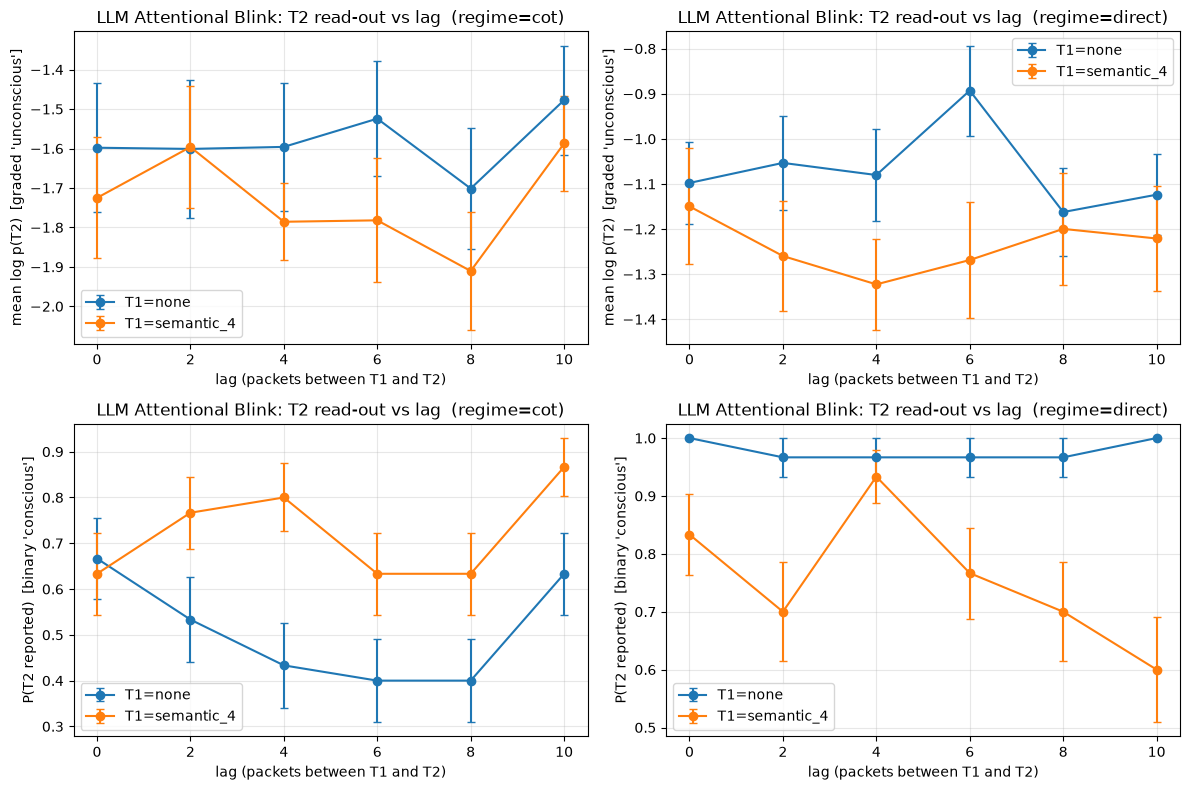

In [13]:
import matplotlib.pyplot as plt
regimes_present = sorted(df["regime"].unique())
has_correct = "report_correct" in df.columns
n_rows = 2 if has_correct else 1
fig, axes = plt.subplots(n_rows, len(regimes_present),
                         figsize=(6 * len(regimes_present), 4 * n_rows), squeeze=False)
for col, regime in enumerate(regimes_present):
    plot_ab(df, "t2_mean_logprob", regime=regime, ax=axes[0, col])      # graded 'unconscious'
    if has_correct:
        plot_ab(df, "report_correct", regime=regime, ax=axes[1, col])   # binary 'conscious'
plt.tight_layout(); plt.show()

## 5. Sanity checks — run BEFORE trusting any curve
See `README.md` -> 'Sanity checks & controls'.

New gate (2026-07-17): **`output_truncated`** — with the old 256-token budget, ~45% of cot trials
re-enumerated the packets inside `<Thinking>` and got cut off before the T2 slot, so they scored
`report_correct=False` for a purely mechanical reason. The budget is now 1024 with an early stop at
`</Final_Answers>`; any trial still flagged here must be excluded (or the budget raised further).

In [14]:
import pandas as pd
# Coerce boolean/None columns to 0/1 floats so means work regardless of dtype.
def _rate(s):
    return s.map({True: 1.0, False: 0.0})   # None / NaN / other -> NaN, skipped by mean()

if "t1_correct" in df.columns:
    print("T1 accuracy by load (should fall with difficulty):")
    print(_rate(df["t1_correct"]).groupby(df["t1_load"]).mean())
if "thinking_is_placeholder" in df.columns:
    cot = df[df.regime == "cot"]
    print("\nCoT placeholder-copy rate (cot rows):", round(_rate(cot["thinking_is_placeholder"]).mean(), 3))
    print("  (high => Qwen skipped real reasoning; the cot/direct contrast is then void)")
if "t2_slot_missing" in df.columns:
    print("T2 slot-missing rate:", round(_rate(df["t2_slot_missing"]).mean(), 3))

if "output_truncated" in df.columns:
    print("\nOutput-truncated rate (hit the max_new_tokens budget):")
    print(df.groupby("regime")["output_truncated"].apply(lambda s: _rate(s).mean()).round(3))
    print("  (>0 => raise max_new_tokens; those trials fail report + get garbage graded scores)")
    if "t2_slot_missing" in df.columns:
        import pandas as pd
        print("\ntruncated x slot_missing (truncation should explain most missing slots):")
        print(pd.crosstab(df["output_truncated"], df["t2_slot_missing"]))

# ---- Gated dataframe: use df_ok for every AB-curve analysis ----
_bad = pd.Series(False, index=df.index)
for col in ("output_truncated", "t2_slot_missing"):
    if col in df.columns:
        _bad |= _rate(df[col]).fillna(0).astype(bool)
df_ok = df[~_bad].copy()
print(f"\nGated df_ok: kept {len(df_ok)}/{len(df)} trials "
      f"({len(df) - len(df_ok)} excluded by truncation / missing T2 slot)")
print("Trials kept per cell (watch for empty/unbalanced cells before averaging):")
print(df_ok.groupby(["regime", "t1_load", "lag"]).size().unstack("lag", fill_value=0))

T1 accuracy by load (should fall with difficulty):
t1_load
none               NaN
semantic_4    0.177778
Name: t1_correct, dtype: float64

CoT placeholder-copy rate (cot rows): 0.025
  (high => Qwen skipped real reasoning; the cot/direct contrast is then void)
T2 slot-missing rate: 0.072

Output-truncated rate (hit the max_new_tokens budget):
regime
cot       0.025
direct    0.000
Name: output_truncated, dtype: float64
  (>0 => raise max_new_tokens; those trials fail report + get garbage graded scores)

truncated x slot_missing (truncation should explain most missing slots):
t2_slot_missing   False  True 
output_truncated              
False               664     47
True                  4      5

Gated df_ok: kept 664/720 trials (56 excluded by truncation / missing T2 slot)
Trials kept per cell (watch for empty/unbalanced cells before averaging):
lag                0   2   4   6   8   10
regime t1_load                           
cot    none        29  28  29  28  28  29
       semanti

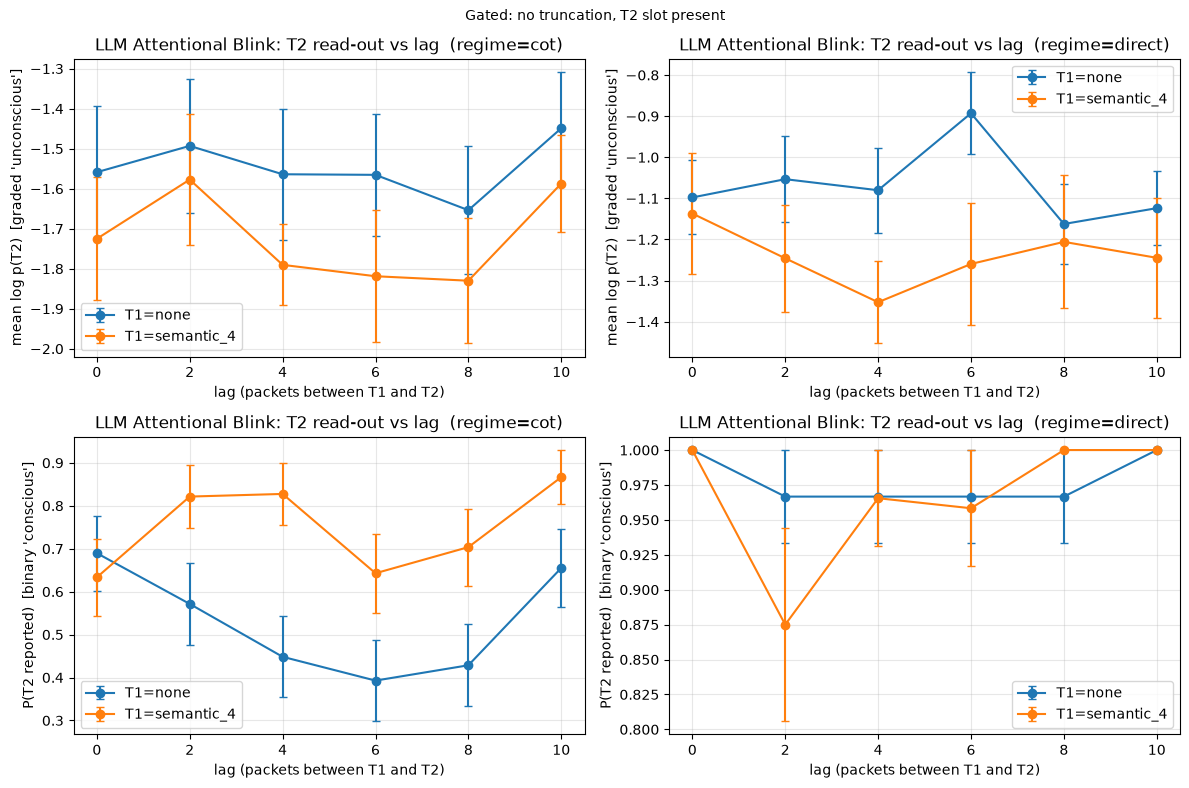

In [15]:
# Same AB figure, but on the GATED data (df_ok) — this is the interpretable version.
import matplotlib.pyplot as plt
regimes_present = sorted(df_ok["regime"].unique())
has_correct = "report_correct" in df_ok.columns
n_rows = 2 if has_correct else 1
fig, axes = plt.subplots(n_rows, len(regimes_present),
                         figsize=(6 * len(regimes_present), 4 * n_rows), squeeze=False)
for col, regime in enumerate(regimes_present):
    plot_ab(df_ok, "t2_mean_logprob", regime=regime, ax=axes[0, col])
    if has_correct:
        plot_ab(df_ok, "report_correct", regime=regime, ax=axes[1, col])
plt.suptitle("Gated: no truncation, T2 slot present", fontsize=10)
plt.tight_layout(); plt.show()


### Also check some examples:

In [17]:
import pandas as pd
from LLM_Blink import build_trial, TrialConfig

def show_trial(row):
    r = df.loc[row] if not isinstance(row, pd.Series) else row
    tr = build_trial(TrialConfig(
        lag=int(r.lag), t1_load=r.t1_load, regime=r.regime, mask=bool(r.mask),
        n_pre=int(r.n_pre), n_post=int(r.n_post), t2_words=int(r.t2_words), seed=int(r.seed),
    ))
    print("=" * 90)
    print(f"lag={r.lag} | load={r.t1_load} | regime={r.regime} | seed={r.seed}")
    print(f"correct T2 = {r.t2_phrase!r} | report_correct={r.report_correct} | t1_correct={r.t1_correct}")
    flags = [c for c in ("output_truncated", "t2_slot_missing", "thinking_is_placeholder")
             if c in r.index and r[c] is True]
    print("quality flags:", ", ".join(flags) if flags else "none")
    print("\n----- STIMULUS (what the model saw) -----\n" + tr.user)
    print("\n----- MODEL OUTPUT (what it answered) -----\n" + str(r.raw_output))

show_trial(100)  

lag=0 | load=semantic_4 | regime=direct | seed=10070
correct T2 = 'INDIA HOTEL SIERRA' | report_correct=True | t1_correct=False
quality flags: none

----- STIMULUS (what the model saw) -----
You will be provided with a stream of sequential data packets. Read the entire stream, then output EXACTLY the template at the end. Do not add conversational text, introductory phrases, or extra punctuation.
EXAMPLE (illustration only - not part of the real stream):
DATA STREAM:
[Packet 01]: System initialization complete. Weather is clear.
[Packet 02]: Update 1.0.3 applied to main server.
[Packet 03 - T1]: LOGIC OVERRIDE. Decide whether SALMON is an ANIMAL or a TOOL. Answer ANIMAL or TOOL.
[Packet 04]: Sensor array recalibrated.
[Packet 05]: Disk usage at 42 percent.
[Packet 06 - T2]: The secure operational passphrase is "VICTOR XRAY ROMEO".
[Packet 07]: Backup job 17 finished successfully.
[Packet 08]: End of stream.
OUTPUT:
<Final_Answers>
Target 2 Result: VICTOR XRAY ROMEO
Target 1 Result: ANIM

## Next steps
- Switch the model cell to `Qwen2.5-1.5B-Instruct` for the real run.
- Confound check: `run_sweep(..., n_pres=(2, 4, 6, 8))` to separate lag from T2 absolute position.
- Add a second model family (e.g. `google/gemma-2-2b-it`) — single-model effects are often idiosyncratic.
- Titrate toward ~50% report via T2 length / mask / distractor similarity (see `../PROMPTS.md` P2).